# Gradient Descent Visualizer

**Question:** What is gradient descent actually doing — and how does learning rate change everything?

This notebook implements gradient descent **from scratch using only NumPy** — no ML frameworks, no black boxes. We then visualize every step so the algorithm becomes intuitive.

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11

FIGURES_DIR = 'figures/'
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.4.4
Setup complete.


## 2. The math — in plain English

Gradient descent answers one question: *given a function, how do I find its minimum?*

The update rule is:

$$x_{new} = x_{old} - \alpha \cdot f'(x_{old})$$

Where:
- $x$ is our current position on the curve
- $f'(x)$ is the **gradient** — the slope at our current position (tells us which way is uphill)
- $\alpha$ (alpha) is the **learning rate** — controls how big each step is
- We **subtract** the gradient to go downhill

That's it. Every neural network in the world runs on this one idea.

## 3. Core implementation — gradient descent from scratch

In [2]:
def gradient_descent(f, df, x_start, learning_rate, n_steps):
    """
    Run gradient descent from scratch.
    
    Args:
        f           : the function we want to minimize e.g. f(x) = x^2
        df          : the derivative (gradient) of f
        x_start     : starting position on the x-axis
        learning_rate: step size (alpha)
        n_steps     : how many steps to take
    
    Returns:
        history: list of (x, f(x)) tuples — the full path taken
    """
    x = x_start
    history = [(x, f(x))]
    
    for _ in range(n_steps):
        gradient = df(x)          # compute slope at current position
        x = x - learning_rate * gradient   # take a step downhill
        history.append((x, f(x)))
    
    return history

print('gradient_descent() function defined.')

gradient_descent() function defined.


## 4. Function 1 — Quadratic: f(x) = x²

The simplest loss surface. One global minimum at x=0. Perfect for understanding the algorithm.

In [3]:
# Define the function and its derivative
f1  = lambda x: x**2          # f(x) = x²
df1 = lambda x: 2*x           # f'(x) = 2x

# Run gradient descent
history = gradient_descent(
    f=f1, df=df1,
    x_start=4.0,
    learning_rate=0.2,
    n_steps=20
)

# Unpack history into x and y lists
xs = [h[0] for h in history]
ys = [h[1] for h in history]

print(f'Started at x={xs[0]:.2f}, f(x)={ys[0]:.4f}')
print(f'Ended   at x={xs[-1]:.4f}, f(x)={ys[-1]:.6f}')
print(f'Steps taken: {len(history)-1}')

Started at x=4.00, f(x)=16.0000
Ended   at x=0.0001, f(x)=0.000000
Steps taken: 20


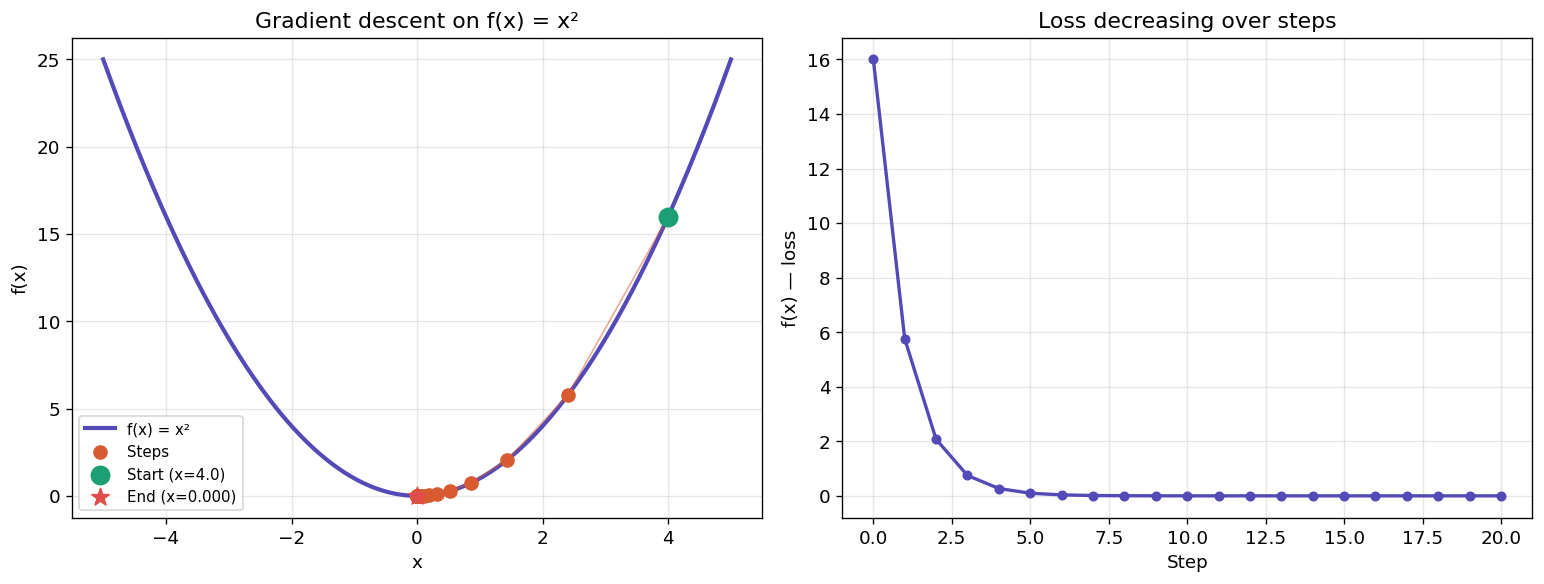

Saved: gd_quadratic.png


In [4]:
# Plot the descent
x_range = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the descent path on the curve
ax = axes[0]
ax.plot(x_range, f1(x_range), color='#534AB7', linewidth=2.5, label='f(x) = x²')
ax.scatter(xs, ys, color='#D85A30', s=60, zorder=5, label='Steps')
ax.plot(xs, ys, color='#D85A30', linewidth=1, alpha=0.5)
ax.scatter(xs[0], ys[0], color='#1D9E75', s=120, zorder=6, label=f'Start (x={xs[0]:.1f})')
ax.scatter(xs[-1], ys[-1], color='#E24B4A', s=120, marker='*', zorder=6, label=f'End (x={xs[-1]:.3f})')
ax.set_title('Gradient descent on f(x) = x²')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: loss curve over steps
ax2 = axes[1]
ax2.plot(range(len(ys)), ys, color='#534AB7', linewidth=2, marker='o', markersize=5)
ax2.set_title('Loss decreasing over steps')
ax2.set_xlabel('Step')
ax2.set_ylabel('f(x) — loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}gd_quadratic.png')
plt.show()
print('Saved: gd_quadratic.png')

**What we see:** *The descent started at x=4.0 and reached x≈0 in 20 steps, 
which is the true minimum of x². The loss curve on the right shows the steepest 
drop in the first 5 steps — this is because the gradient is largest far from the 
minimum, so steps are bigger. As we get closer to x=0 the gradient shrinks, steps 
get smaller, and the curve flattens out. This "fast at first, slow near the end" 
behaviour is normal and expected for gradient descent on a convex surface.*

---

## 5. Learning rate comparison — the most important experiment

The learning rate $\alpha$ is the most critical hyperparameter. Too small and training never finishes. Too large and it overshoots and diverges. We'll visualize all three cases side by side.

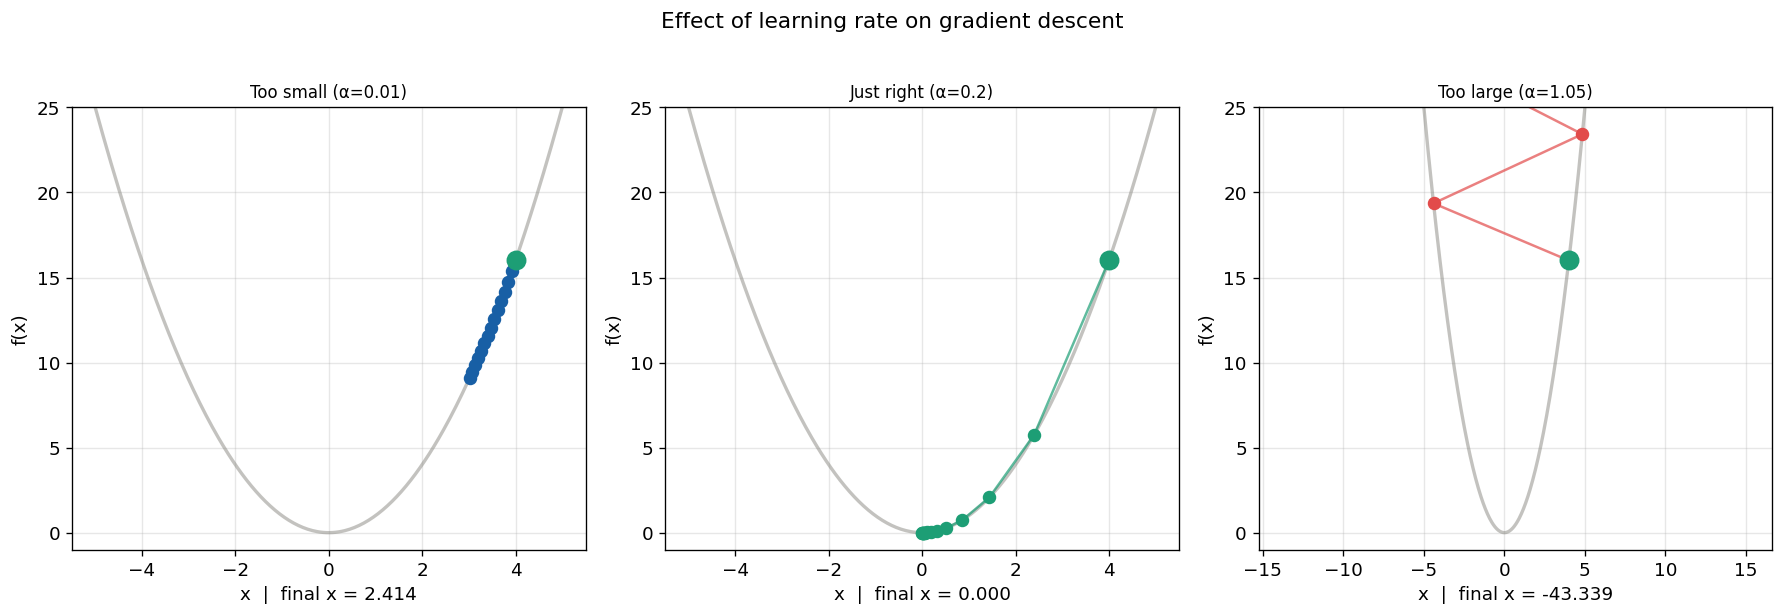

Saved: learning_rate_compare.png


In [5]:
learning_rates = {
    'Too small (α=0.01)':  0.01,
    'Just right (α=0.2)':  0.2,
    'Too large (α=1.05)':  1.05,
}

colors = ['#185FA5', '#1D9E75', '#E24B4A']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_range = np.linspace(-5, 5, 300)

for ax, (label, lr), color in zip(axes, learning_rates.items(), colors):
    history = gradient_descent(f1, df1, x_start=4.0, learning_rate=lr, n_steps=25)
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    # Clamp for display so diverging runs don't break the axis
    ys_clamped = [min(y, 50) for y in ys]
    
    ax.plot(x_range, f1(x_range), color='#888780', linewidth=2, alpha=0.5)
    ax.scatter(xs[:15], ys_clamped[:15], color=color, s=50, zorder=5)
    ax.plot(xs[:15], ys_clamped[:15], color=color, linewidth=1.5, alpha=0.7)
    ax.scatter(xs[0], ys[0], color='#1D9E75', s=120, zorder=6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-1, 25)
    ax.grid(True, alpha=0.3)
    
    final_x = xs[-1]
    ax.set_xlabel(f'x  |  final x = {final_x:.3f}')

plt.suptitle('Effect of learning rate on gradient descent', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}learning_rate_compare.png')
plt.show()
print('Saved: learning_rate_compare.png')

**What we see:**
- **Too small (0.01):** Takes tiny steps — makes progress but extremely slowly. In a real neural network this means training for days instead of hours.
- **Just right (0.2):** Smoothly descends to the minimum in ~15 steps. This is what we want.
- **Too large (1.05):** Overshoots the minimum, bounces back and forth, and diverges. The loss goes UP instead of down.

---

## 6. Function 2 — Non-convex: f(x) = x⁴ - 4x² + x

A trickier surface with **two local minima**. This shows that gradient descent finds *a* minimum, not necessarily the *global* minimum — a crucial limitation to understand.

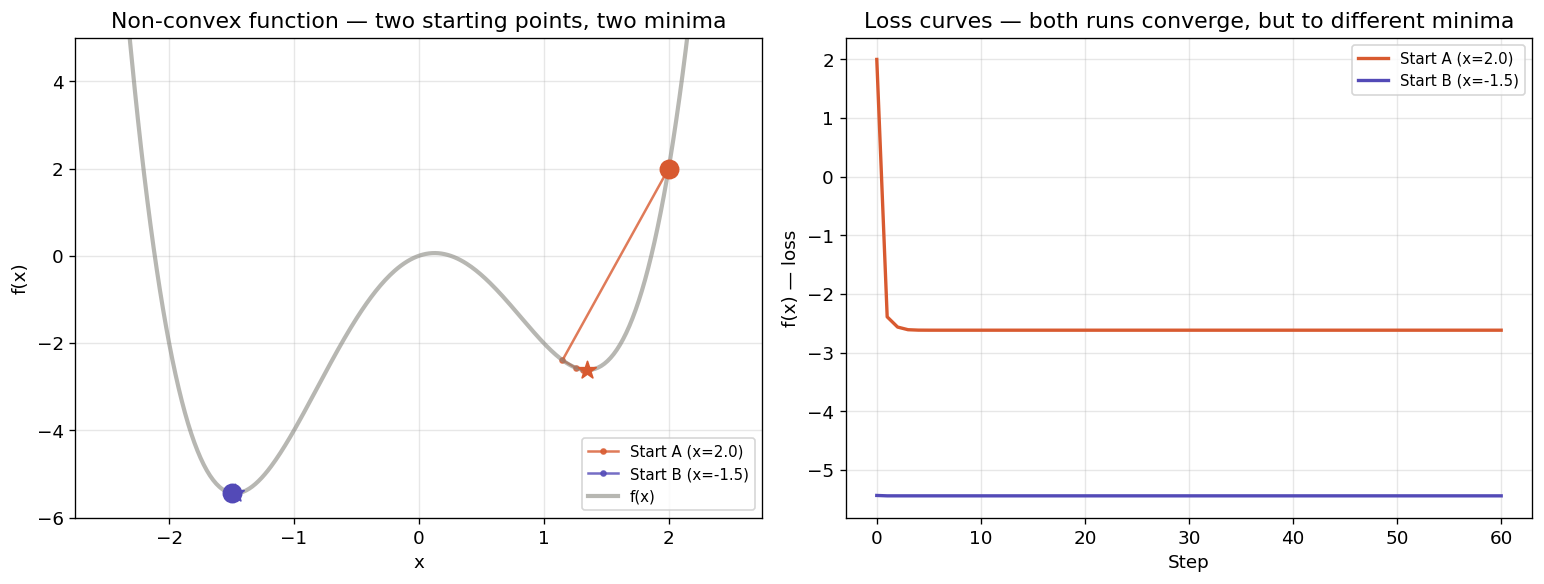

Saved: gd_nonconvex.png


In [6]:
f2  = lambda x: x**4 - 4*x**2 + x
df2 = lambda x: 4*x**3 - 8*x + 1

x_range = np.linspace(-2.5, 2.5, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

start_points = [2.0, -1.5]   # two different starting points
start_colors = ['#D85A30', '#534AB7']
labels = ['Start A (x=2.0)', 'Start B (x=-1.5)']

for ax_idx, (start, color, lbl) in enumerate(zip(start_points, start_colors, labels)):
    history = gradient_descent(f2, df2, x_start=start, learning_rate=0.05, n_steps=60)
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    axes[0].plot(xs, ys, color=color, linewidth=1.5, alpha=0.8, marker='o', markersize=3, label=lbl)
    axes[0].scatter(xs[0], ys[0], color=color, s=120, zorder=6)
    axes[0].scatter(xs[-1], ys[-1], color=color, s=120, marker='*', zorder=6)

axes[0].plot(x_range, f2(x_range), color='#888780', linewidth=2.5, alpha=0.6, label='f(x)')
axes[0].set_title('Non-convex function — two starting points, two minima')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-6, 5)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: loss curves for both runs
for start, color, lbl in zip(start_points, start_colors, labels):
    history = gradient_descent(f2, df2, x_start=start, learning_rate=0.05, n_steps=60)
    ys = [h[1] for h in history]
    axes[1].plot(ys, color=color, linewidth=2, label=lbl)

axes[1].set_title('Loss curves — both runs converge, but to different minima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('f(x) — loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}gd_nonconvex.png')
plt.show()
print('Saved: gd_nonconvex.png')

**What we see:** *Two starting points on the same function lead to two completely 
different minima. Start A (x=2.0) gets trapped in the right valley, while Start B 
(x=-1.5) finds the deeper left valley. Both successfully reduce their loss — but 
Start B found a better solution. Gradient descent is greedy: it always goes downhill 
locally, but has no knowledge of what lies in other parts of the surface. This is 
why weight initialization in neural networks is not random — techniques like Xavier 
and He initialization are designed to start training in regions more likely to lead 
to good minima.*

*The starting point determines which minimum gradient descent finds. This is why neural network weight **initialization** matters — it determines which part of the loss surface you start exploring.*

---

## 7. 2D loss surface — a taste of what happens in neural networks

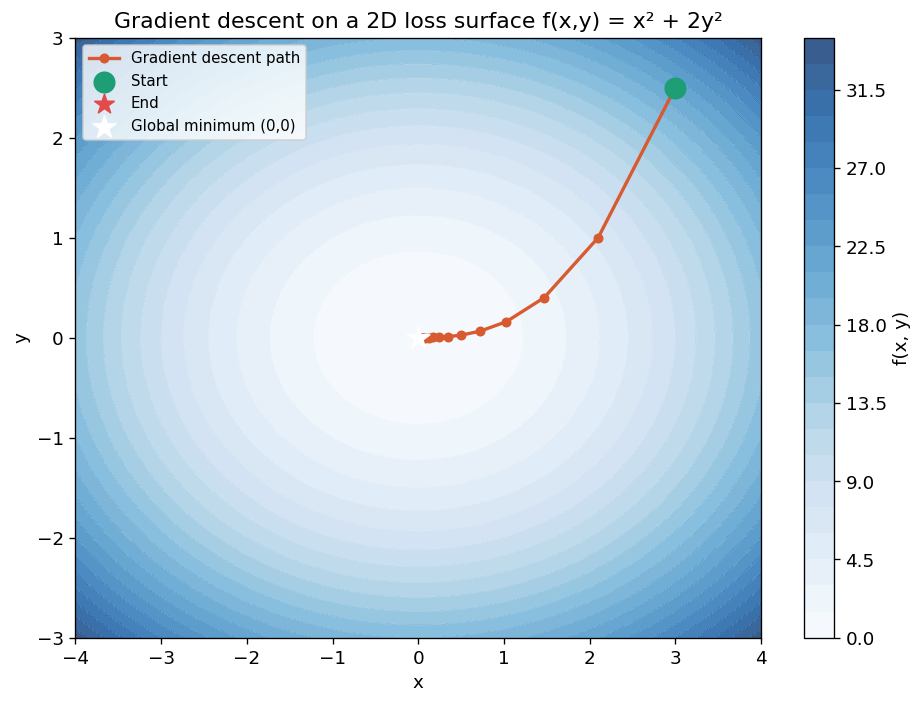

Saved: gd_2d_surface.png


In [7]:
# 2D function: f(x, y) = x^2 + 2*y^2  (bowl shape)
f3  = lambda x, y: x**2 + 2*y**2
df3 = lambda x, y: np.array([2*x, 4*y])   # gradient vector

def gradient_descent_2d(df, start, lr, n_steps):
    pos = np.array(start, dtype=float)
    history = [pos.copy()]
    for _ in range(n_steps):
        grad = df(pos[0], pos[1])
        pos = pos - lr * grad
        history.append(pos.copy())
    return np.array(history)

path = gradient_descent_2d(df3, start=[3.0, 2.5], lr=0.15, n_steps=30)

# Create contour plot
x = np.linspace(-4, 4, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = f3(X, Y)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y, Z, levels=25, cmap='Blues', alpha=0.8)
ax.contour(X, Y, Z, levels=25, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=ax, label='f(x, y)')

ax.plot(path[:, 0], path[:, 1], 'o-', color='#D85A30', linewidth=2,
        markersize=5, label='Gradient descent path')
ax.scatter(path[0, 0], path[0, 1], color='#1D9E75', s=150, zorder=6, label='Start')
ax.scatter(path[-1, 0], path[-1, 1], color='#E24B4A', s=150, marker='*', zorder=6, label='End')
ax.scatter(0, 0, color='white', s=200, marker='*', zorder=7, label='Global minimum (0,0)')

ax.set_title('Gradient descent on a 2D loss surface f(x,y) = x² + 2y²')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}gd_2d_surface.png')
plt.show()
print('Saved: gd_2d_surface.png')

**What we see:** *We started at position (3.0, 2.5) in the top-right corner of the 
surface — the lightest blue, highest loss region. The first steps are large because 
the gradient is steep far from the center. As the path moves inward toward (0, 0), 
the contour rings get tighter, the gradient shrinks, and the steps get smaller. The 
path curves rather than going straight because the surface is asymmetric — y is 
scaled by 2 so the y-direction pulls twice as hard as x, causing the curve to 
flatten along y first. The end point lands right on the global minimum at (0, 0) 
where loss = 0.*

In real neural networks, the loss surface has **millions of dimensions** instead of 2 — but gradient descent runs the exact same update rule in each dimension simultaneously.

---

## 8. Key insights summary

1. **Gradient descent is the engine of all ML.** Every neural network — GPT, ResNet, BERT — learns by running this same update rule millions of times.

2. **Learning rate is the most critical hyperparameter.** Too small = slow training. Too large = divergence. Finding the right value is more art than science, which is why techniques like learning rate scheduling and Adam optimizer exist.

3. **Gradient descent finds local minima, not global ones.** On non-convex surfaces (like all real neural network loss landscapes), where you start determines where you end up. This is why weight initialization strategies matter.

4. **The 2D case is a toy.** Real models have billions of parameters — billions of dimensions. But the math is identical. This is why understanding the 1D case deeply transfers directly to intuition about deep learning.

**What I would do next (Phase 3):** Implement a full neural network forward and backward pass from scratch using this same gradient update rule, but applied to every weight in the network simultaneously.